# Objective

The objective of this notebook is to:
- See if higher resolution can make a better model
- Try to pinpoint the cause of only grey images
- Try to better the image generation, by seeing if there is any improvement with data augmentation

In [109]:
import tensorflow as tf
from tensorflow import keras
import math
#from keras.layers import Conv2D, Conv2DTranspose, MaxPooling2D, Flatten, Dense, Lambda, Reshape

from keras import ops
from keras import layers

from keras import Model, Input
from keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
import os 
import sys

sys.path.append(os.path.abspath('..'))
from proyecto1_deep_learning.data_loader import load_data_full



In [110]:
x_train, x_test = load_data_full()
print(f"Training set shape: {x_train.shape}")
print(f"Testing set shape: {x_test.shape}")

Training set shape: (168, 256, 256, 3)
Testing set shape: (43, 256, 256, 3)


In [111]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 5085250218313283818
xla_global_id: -1
]
2.20.0
Num GPUs Available:  0


In [112]:
x_train.shape, x_test.shape

((168, 256, 256, 3), (43, 256, 256, 3))

In [113]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

print(f'x_train min: {x_train.min()}, max: {x_train.max()}')
print(f'x_test min: {x_test.min()}, max: {x_test.max()}')

x_train min: 0.0, max: 1.0
x_test min: 0.0, max: 1.0


## variational autencoder

to my understanding, generally is:
* we have the original or master latent space whcih we are trying to achieve.
* usually we basically translate neurons language into  a latent space by losing information, and making the language it speaks to say more complex, or so that the general directions which it aims to have mroe meaning. it also means that because each neron has more menaing and is more complex understanding how each position or movement through 3d space makes no sesnse because it chose how to organize itself.
* so in this particalr scenario we give it a language of how to translate into latent space.
* we are basically discifering ho to translate languages or information. so to translate information we first translate the ideal latent space representation or what the model should look like if done like a classic AE, and then we translate as to how taht would look in a noraml distribution. we cast it to a normal distrivution. if we have point a, then its probably in point b, and so on. thus showing spacial relevance.
* and from this normal distribution we can recreate the image.


## first lets do on elike this link:
https://keras.io/examples/generative/vae/ 

In [114]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon


In [115]:
latent_dim = 2
image_size_x = 256
image_size_y = 256
BETA = 1

encoder_inputs = keras.Input(shape=(image_size_x, image_size_y, 3))

x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

shape_before_flattening = x.shape[1:]

x = layers.Flatten()(x)
x = layers.Dense(16)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


latent_inputs = keras.Input(shape=(latent_dim,))

x = layers.Dense(int(np.prod(shape_before_flattening)))(latent_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Reshape(shape_before_flattening)(x)

x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

decoder_outputs = layers.Conv2DTranspose(
    3, 3, activation="sigmoid", padding="same"
)(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_16[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_70       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 64, 64,    │     18,496 │ activation_70[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_71       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 32, 32,    │     73,856 │ activation_71[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_72       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 16, 16,    │    295,168 │ activation_72[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_35[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_73       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 65536)     │          0 │ activation_73[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 16)        │  1,048,592 │ flatten_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_74       │ (None, 16)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,439,060 (5.49 MB)

 Trainable params: 1,438,068 (5.49 MB)

 Non-trainable params: 992 (3.88 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 65536)          │       196,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 65536)          │       262,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_75 (Activation)      │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_30             │ (None, 32, 32, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_76 (Activation)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_31             │ (None, 64, 64, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_77 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_32             │ (None, 128, 128, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_78 (Activation)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_33             │ (None, 256, 256, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_79          │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_79 (Activation)      │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_34             │ (None, 256, 256, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,438,915 (5.49 MB)

 Trainable params: 1,306,883 (4.99 MB)

 Non-trainable params: 132,032 (515.75 KB)

In [116]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # MSE loss (no automatic reduction)
            reconstruction_loss = ops.mean(
                ops.sum(
                    ops.square(data - reconstruction),
                    axis=(1, 2, 3),
                )
            )

            # KL divergence
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + BETA * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [117]:
motorcycle_brum_brum = np.concatenate([x_train, x_test], axis=0)


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
history = vae.fit(x=x_train, epochs=60)

Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - kl_loss: 1954.5128 - loss: 36381.2070 - reconstruction_loss: 34426.6953
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - kl_loss: 8.3794 - loss: 18233.2559 - reconstruction_loss: 18224.8770
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - kl_loss: 7.7894 - loss: 14176.4414 - reconstruction_loss: 14168.6523
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - kl_loss: 0.5502 - loss: 9883.8564 - reconstruction_loss: 9883.3057 
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - kl_loss: 0.2088 - loss: 9289.4902 - reconstruction_loss: 9289.2803
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - kl_loss: 0.8877 - loss: 8711.6006 - reconstruction_loss: 8710.7139
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - kl_loss: 1.6704 - loss: 8717.1553 - reconstruction_loss: 8715.4844
Epoch 8/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - kl_loss: 1.7847 - loss: 8687.9717 - reconstruction_loss: 8686.1865
Epoch 9/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - kl_l

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


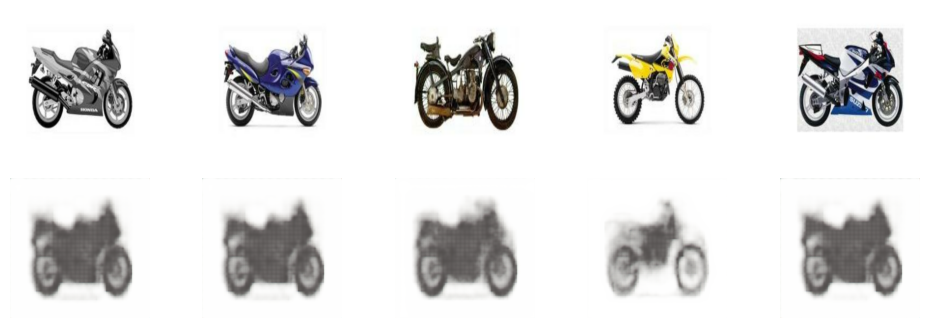

In [122]:
import matplotlib.pyplot as plt
import numpy as np

def show_reconstructions(model, data, n=5):
    z_mean, z_log_var, z = model.encoder.predict(data[:n])
    reconstructions = model.decoder.predict(z_mean)

    plt.figure(figsize=(12, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i])
        plt.axis("off")

        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructions[i])
        plt.axis("off")

    plt.show()

show_reconstructions(vae, motorcycle_brum_brum)

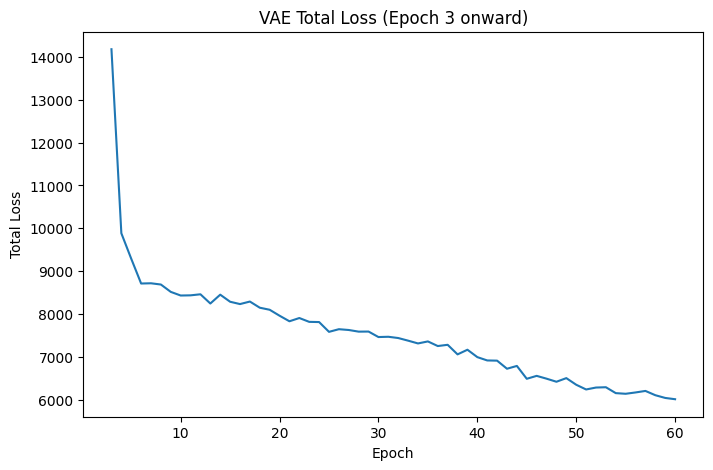

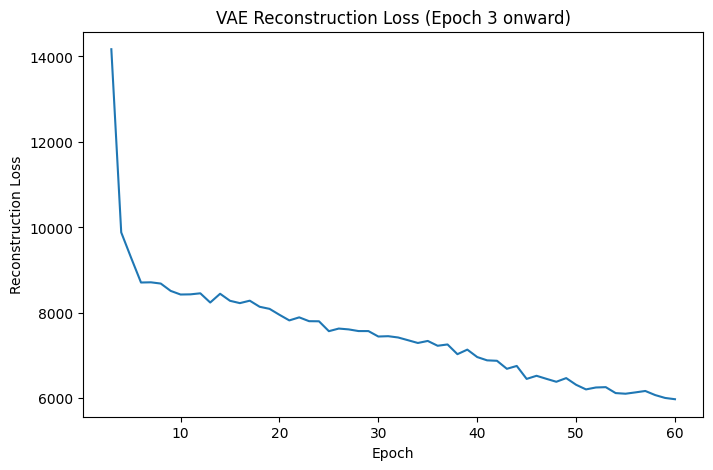

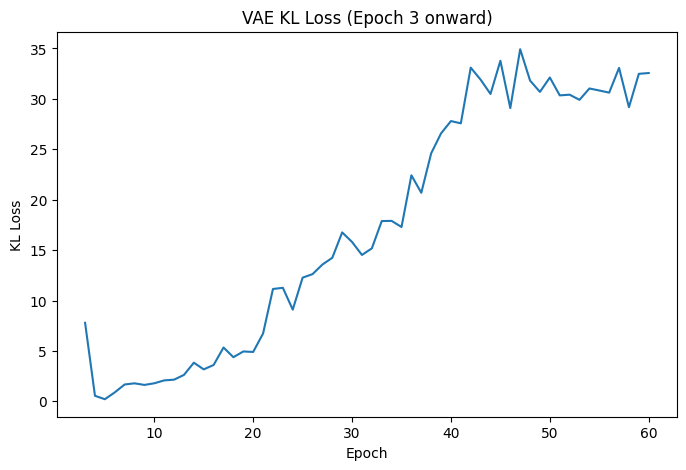

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Ignore first 2 epochs
epochs = np.arange(3, len(history.history["loss"]) + 1)

total_loss = history.history["loss"][2:]
recon_loss = history.history["reconstruction_loss"][2:]
kl_loss = history.history["kl_loss"][2:]

# ---- Total Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, total_loss)
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("VAE Total Loss (Epoch 3 onward)")
plt.show()

# ---- Reconstruction Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, recon_loss)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("VAE Reconstruction Loss (Epoch 3 onward)")
plt.show()

# ---- KL Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, kl_loss)
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("VAE KL Loss (Epoch 3 onward)")
plt.show()

In [124]:
LATENT_DIM = 2

def generate_images(
    decoder: keras.Model,
    n_images: int,
) -> np.ndarray:
    """Sample n_images points from N(0, I) and decode them into images.

    Args:
        decoder:   The standalone decoder model.
        n_images:  How many images to generate.

    Returns:
        numpy array of shape (n_images, H, W, C) with pixel values in [0, 1].
    """
    z = np.random.normal(size=(n_images, LATENT_DIM)).astype("float32")
    generated = decoder.predict(z, verbose=0)
    return generated


def plot_generated_images(
    generated: np.ndarray,
    n_images: int,
    #save_path: str = None,
) -> None:
    """Plot and save generated images.

    Args:
        generated:  numpy array of generated images.
        n_images:   How many images to plot.
        save_path:  Where to save the figure (auto-named if None).
    """
    cols = min(n_images, 5)
    rows = math.ceil(n_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(f"Generated Images (n={n_images})", fontsize=12)

    axes_flat = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes_flat):
        if i < n_images:
            ax.imshow(np.clip(generated[i], 0, 1))
        ax.axis("off")

    plt.tight_layout()

    #if save_path is None:
    #    save_path = f"./reports/figures/3.04-smdeo-generated_images_{n_images}.png"
    #plt.savefig(save_path, dpi=150)
    plt.show()
    #print(f"Generated images saved to {save_path}")


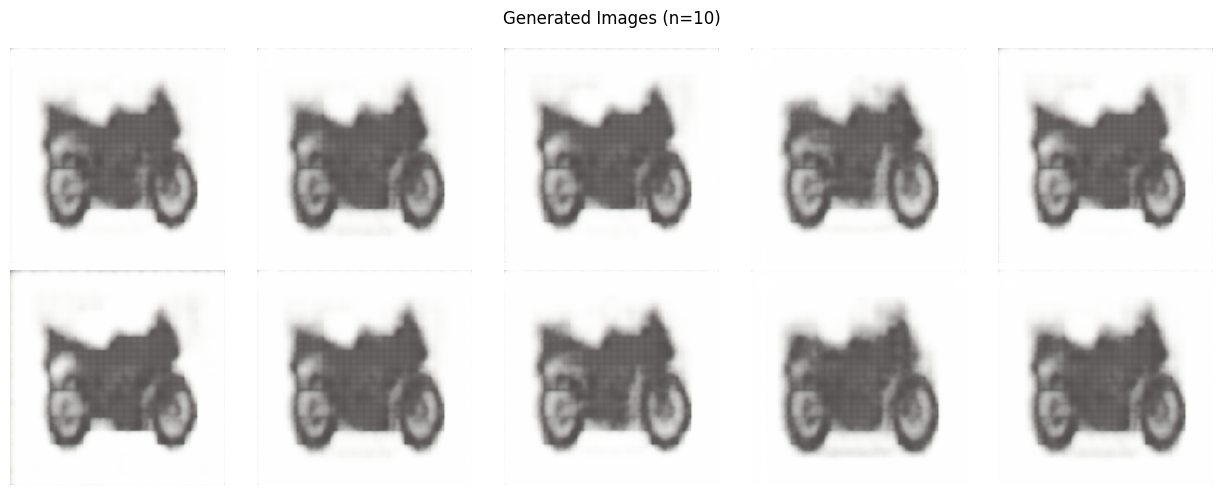

In [125]:
generated_images = generate_images(decoder, n_images=10)
plot_generated_images(generated_images, n_images=10)

# First conclusions

By raising the images resolution, a better image generation is obtained, compared to the model without it, however, images are still gray and it seems that the distribution is not wide enough to generate sufficiently different images when sampling

Potential issues:
- MSE loss
- Latent dimension too low to keep colors as a dimension
